# Week 4 — Preparing the Data

**Course:** AIT506 — Machine Learning
**Checklist section:** *Prepare the Data* (Géron, 2022, Appendix A)

Week 3 left us with a decision to pivot away from the small synthetic Kaggle dataset toward IBM's Telco Customer Churn dataset, mainly because the original data was too thin (2,800 rows, 10 columns, an unrealistic ~57% churn rate) to support the cost-sensitive framing from Week 2. This notebook picks up from that decision: we load the Telco dataset, clean it up, deal with the couple of things that would otherwise leak the answer straight into the model, engineer a few new features, split the data, and build a reusable preprocessing pipeline that Weeks 5 and 6 will load instead of repeating this work from scratch.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "Telco_customer_churn.xlsx"
FIG_DIR = PROJECT_ROOT / "figures" / "week4_prepare_the_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the pivoted dataset

We're working with IBM's Telco Customer Churn dataset now, not the small Kaggle sample from Week 3.

In [2]:
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [3]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

## 2. Check for missing or structurally odd data

Nothing shows up as a conventional `NaN` except one column, but that one column isn't really "missing data" in the usual sense — it only exists for customers who churned, since a reason can't be recorded for someone who didn't leave.

In [4]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

Churn Reason    5174
dtype: int64

In [5]:
# Total Charges is stored as text (object dtype) even though it looks numeric.
# Coercing it to numeric surfaces the real missing-data problem: brand-new customers
# with zero completed billing cycles get a blank string instead of 0.
total_charges_numeric = pd.to_numeric(df["Total Charges"], errors="coerce")
blank_mask = total_charges_numeric.isna()
print(f"Rows where Total Charges is blank: {blank_mask.sum()}")
df.loc[blank_mask, ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges"]]

Rows where Total Charges is blank: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,
2438,3115-CZMZD,0,20.25,
2568,5709-LVOEQ,0,80.85,
2667,4367-NUYAO,0,25.75,
2856,1371-DWPAZ,0,56.05,
4331,7644-OMVMY,0,19.85,
4687,3213-VVOLG,0,25.35,
5104,2520-SGTTA,0,20.00,
5719,2923-ARZLG,0,19.70,
6772,4075-WKNIU,0,73.35,


Every one of those rows has `Tenure Months == 0` — these are customers who signed up but haven't completed a billing cycle yet, so there's nothing to sum into a total. Imputing the column mean or median here would invent billing history that doesn't exist; the value that's actually true for a customer with zero completed cycles is 0, so that's what we fill in.

In [6]:
df["Total Charges"] = total_charges_numeric
df["Total Charges"] = df["Total Charges"].fillna(0.0)
assert df["Total Charges"].isnull().sum() == 0
print("Total Charges is now fully numeric, no missing values.")

Total Charges is now fully numeric, no missing values.


## 3. Drop identifier, constant, and leakage columns

A few columns need to go before modeling, each for a different reason:

- **`CustomerID`** — a unique key, not a feature.
- **`Count`, `Country`, `State`** — constant across all 7,043 rows (every row is `1`, `United States`, `California`), so they carry zero information.
- **`Zip Code`, `Lat Long`, `Latitude`, `Longitude`, `City`** — all customers are in California, and `City` alone has 1,129 distinct values across 7,043 rows (about 6 rows per city on average). One-hot encoding that would add over a thousand near-empty columns for very little predictive payoff, so we leave geography out of this iteration and note it as a possible future refinement rather than force it in now.
- **`Churn Label`** — a text duplicate of `Churn Value` (the numeric target we'll actually use).
- **`Churn Score`, `CLTV`, `Churn Reason`** — this is the leakage concern. `Churn Reason` is only ever populated for customers who already churned, so its mere presence/absence gives the answer away directly. `Churn Score` and `CLTV` are IBM's own precomputed propensity and lifetime-value scores — outputs of some other model, not raw customer attributes — and `Churn Score` alone correlates with our target at r ≈ 0.66, which is far too strong for a feature that's supposed to be an input rather than a restatement of the label. Sasse et al. (2025) describe exactly this pattern — a feature that's really a downstream artifact of the target — as one of the most common ways leakage sneaks into a supervised pipeline. We keep `Churn Score` around separately, off to the side, as a benchmark to compare our own models against in Week 5, rather than as a training feature.

In [7]:
leakage_or_uninformative_cols = [
    "CustomerID", "Count", "Country", "State",
    "Zip Code", "Lat Long", "Latitude", "Longitude", "City",
    "Churn Label", "CLTV", "Churn Reason",
]

churn_score_benchmark = df["Churn Score"].copy()

df_model = df.drop(columns=leakage_or_uninformative_cols + ["Churn Score"])
print(f"Columns dropped: {len(leakage_or_uninformative_cols) + 1}")
print(f"Remaining shape: {df_model.shape}")
df_model.columns.tolist()

Columns dropped: 13
Remaining shape: (7043, 20)


['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value']

## 4. Confirm the target variable

`Churn Value` is already a clean 0/1 encoding — no work needed there beyond checking that it's balanced enough to model and consistent with the label it was derived from.

Churn Value
Stayed     0.7346
Churned    0.2654
Name: proportion, dtype: float64


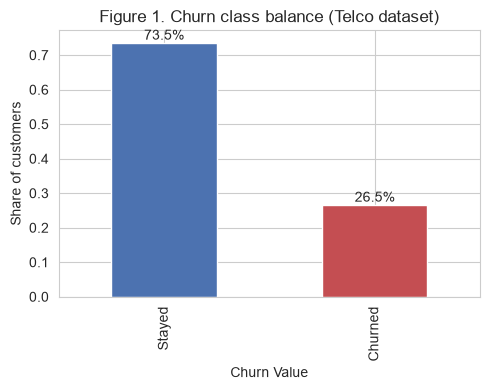

In [8]:
churn_balance = df_model["Churn Value"].value_counts(normalize=True).rename({0: "Stayed", 1: "Churned"})
print(churn_balance.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
churn_balance.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_ylabel("Share of customers")
ax.set_title("Figure 1. Churn class balance (Telco dataset)")
for i, v in enumerate(churn_balance.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_churn_balance.png", dpi=150)
plt.show()

About 1 in 4 customers in this dataset churned (26.5%) versus roughly 3 in 4 who stayed. That's a real, moderate class imbalance — nowhere near as severe as some churn datasets get, but enough that plain accuracy would still be a misleading headline metric, consistent with what we flagged as a risk back in Week 2. It's also a much more believable base rate than the roughly 57% churn rate in the Week 3 dataset, which is part of why we pivoted.

## 5. Engineer a few new features

Three small, interpretable features, each grounded in something we already suspected mattered from the Week 2 literature review or the Week 3 exploratory findings:

1. **`Num_Addon_Services`** — a count (0–6) of how many of the six optional add-ons (`Online Security`, `Online Backup`, `Device Protection`, `Tech Support`, `Streaming TV`, `Streaming Movies`) a customer has switched on. This is meant to capture overall product engagement in a single number instead of six separate categorical columns pulling in different directions.
2. **`AutoPay`** — a binary flag for whether the customer's `Payment Method` is one of the two automatic options (bank transfer or credit card, both marked "(automatic)" in the raw data) versus a manual one (mailed check or electronic check). The idea, backed by the general churn-driver literature (Imani et al., 2025), is that payment friction (a expiring card, a forgotten manual payment) is itself a churn trigger, so autopay customers should be a bit stickier, all else equal.
3. **`IsNewCustomer`** — a binary flag for `Tenure Months <= 6`. Early tenure is one of the most consistently reported churn drivers across industries (Imani et al., 2025), and it echoes what our teammate found in the Week 3 EDA on the old dataset, where a longer stretch since last login (a proxy for a shaky early relationship) tracked with higher churn.

In [9]:
addon_cols = [
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
]
df_model["Num_Addon_Services"] = (df_model[addon_cols] == "Yes").sum(axis=1)

df_model["AutoPay"] = df_model["Payment Method"].str.contains("automatic", case=False).astype(int)

df_model["IsNewCustomer"] = (df_model["Tenure Months"] <= 6).astype(int)

df_model[["Num_Addon_Services", "AutoPay", "IsNewCustomer"]].describe()

,Num_Addon_Services,AutoPay,IsNewCustomer
count,7043.000000,7043.000000,7043.000000
mean,2.037910,0.435326,0.210280
std,1.847682,0.495835,0.407536
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,3.000000,1.000000,0.000000
max,6.000000,1.000000,1.000000


Tenure Months        -0.352
AutoPay              -0.210
Total Charges        -0.198
Num_Addon_Services   -0.088
Monthly Charges       0.193
IsNewCustomer         0.309
Name: Churn Value, dtype: float64


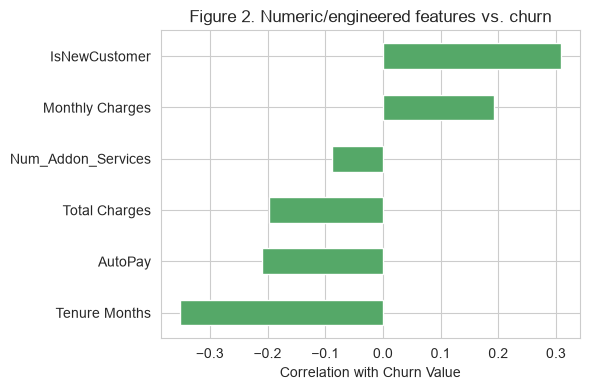

In [10]:
engineered = ["Num_Addon_Services", "AutoPay", "IsNewCustomer", "Tenure Months", "Monthly Charges", "Total Charges"]
corr_with_churn = df_model[engineered + ["Churn Value"]].corr()["Churn Value"].drop("Churn Value").sort_values()
print(corr_with_churn.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
corr_with_churn.plot(kind="barh", color="#55A868", ax=ax)
ax.set_xlabel("Correlation with Churn Value")
ax.set_title("Figure 2. Numeric/engineered features vs. churn")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_engineered_feature_correlation.png", dpi=150)
plt.show()

`IsNewCustomer` turned out to be the strongest of the three, `AutoPay` came out negative as expected (autopay customers churn less), and `Num_Addon_Services` is negative too — more add-ons, more engagement, less churn, which lines up with the "more involved customers stay longer" pattern our teammate already saw in Week 3 on a completely different dataset. `Tenure Months` on its own is the single strongest numeric predictor here, which is exactly why we bucketed it into `IsNewCustomer` in the first place — most of its signal is concentrated at the low end.

## 6. Train/test split

Same plan flagged in Week 3: an 80/20 split, stratified on `Churn Value` so both sides keep the same ~26.5/73.5 balance, with a fixed `random_state` so the split is reproducible across the team's machines.

In [11]:
target = "Churn Value"
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, churn rate {y_train.mean():.4f}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.4f}")

Train: (5634, 22), churn rate 0.2654
Test:  (1409, 22), churn rate 0.2654


## 7. Build the preprocessing pipeline (encoding + scaling)

Rather than hand-transform each column, we build a single `ColumnTransformer` — numeric columns get standardized (mean 0, unit variance, which matters for Logistic Regression, SVM, and the neural-net baseline we'll try in Week 5 but does nothing to hurt the tree-based models), and categorical columns get one-hot encoded (Kuhn & Johnson, 2013). Fitting it only on the training split and reusing it on the test split keeps the test set genuinely unseen, which is the same discipline Sasse et al. (2025) point to as the difference between a leakage-free pipeline and one that quietly inflates its own scores.

In [12]:
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges", "Num_Addon_Services"]
categorical_features = [c for c in X_train.columns if c not in numeric_features + ["AutoPay", "IsNewCustomer"]]
passthrough_features = ["AutoPay", "IsNewCustomer"]  # already 0/1, nothing to do

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
    ("bin", "passthrough", passthrough_features),
])

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out().tolist()
print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")
print(f"Total engineered feature columns after encoding: {len(feature_names)}")

Processed train shape: (5634, 43)
Processed test shape:  (1409, 43)
Total engineered feature columns after encoding: 43


## 8. Sanity checks before moving on

Quick checks that the pipeline did what we expect: no `NaN`s slipped through, the encoded shapes agree between train and test, and the class balance held up on both sides of the split.

In [13]:
assert not np.isnan(X_train_processed).any(), "NaNs found in processed train set"
assert not np.isnan(X_test_processed).any(), "NaNs found in processed test set"
assert X_train_processed.shape[1] == X_test_processed.shape[1] == len(feature_names)
print("All sanity checks passed.")
print("First 10 feature names:", feature_names[:10])

All sanity checks passed.
First 10 feature names: ['num__Tenure Months', 'num__Monthly Charges', 'num__Total Charges', 'num__Num_Addon_Services', 'cat__Gender_Male', 'cat__Senior Citizen_Yes', 'cat__Partner_Yes', 'cat__Dependents_Yes', 'cat__Phone Service_Yes', 'cat__Multiple Lines_No']


## 9. Persist the processed data for Weeks 5 and 6

So the next two weeks can load a train/test split and a fitted preprocessing pipeline instead of re-running this notebook, we save everything to `data/processed/`. We also keep the cleaned-but-not-yet-encoded dataframe as a CSV, and the `Churn Score` benchmark column aligned to the same train/test row split, so Week 5 can use it as a "what would IBM's own score have gotten us" comparison point.

In [14]:
np.save(PROCESSED_DIR / "X_train.npy", X_train_processed)
np.save(PROCESSED_DIR / "X_test.npy", X_test_processed)
np.save(PROCESSED_DIR / "y_train.npy", y_train.to_numpy())
np.save(PROCESSED_DIR / "y_test.npy", y_test.to_numpy())

joblib.dump(preprocessor, PROCESSED_DIR / "preprocessor.joblib")

with open(PROCESSED_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

df_model.to_csv(PROCESSED_DIR / "telco_cleaned.csv", index=False)

churn_score_train = churn_score_benchmark.loc[X_train.index].to_numpy()
churn_score_test = churn_score_benchmark.loc[X_test.index].to_numpy()
np.save(PROCESSED_DIR / "churn_score_benchmark_train.npy", churn_score_train)
np.save(PROCESSED_DIR / "churn_score_benchmark_test.npy", churn_score_test)

print("Saved to:", PROCESSED_DIR)
for p in sorted(PROCESSED_DIR.iterdir()):
    print(" -", p.name)

Saved to: /Users/hangtran/Documents/projects/ait506-group-project-customer-churn/data/processed
 - X_test.npy
 - X_train.npy
 - churn_score_benchmark_test.npy
 - churn_score_benchmark_train.npy
 - feature_names.json
 - preprocessor.joblib
 - telco_cleaned.csv
 - y_test.npy
 - y_train.npy


## Summary

Starting from the 7,043-row, 33-column Telco dataset, we fixed the one real missing-data issue (11 brand-new customers with a blank `Total Charges`, filled with 0 since that's literally true for them), dropped 13 columns that were either uninformative (constant, an ID, over-granular geography) or outright leaked the target (`Churn Reason`, `Churn Score`, `CLTV`), added three engineered features grounded in the churn-driver literature and last week's EDA, and produced a clean, encoded, stratified 80/20 train/test split that one-hot encoding expands to 43 processed feature columns. Everything downstream — Week 5's model comparison and Week 6's tuning — will load these same saved arrays and the same fitted preprocessing pipeline, so every week from here on is comparing models on identical, already-agreed-upon data rather than quietly re-deriving it.

## References

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

Imani, M., Joudaki, M., Beikmohammadi, A., & Arabnia, H. (2025). Customer churn prediction: A systematic review of recent advances, trends, and challenges in machine learning and deep learning. *Machine Learning and Knowledge Extraction, 7*(3), Article 105. https://doi.org/10.3390/make7030105

Kuhn, M., & Johnson, K. (2013). *Applied predictive modeling*. Springer. https://doi.org/10.1007/978-1-4614-6849-3

Sasse, L., Nicolaisen-Sobesky, E., Dukart, J., Eickhoff, S. B., Götz, M., Hamdan, S., Komeyer, V., Kulkarni, A., Lahnakoski, J. M., Love, B. C., Raimondo, F., & Patil, K. R. (2025). Overview of leakage scenarios in supervised machine learning. *Journal of Big Data, 12*(1), Article 130. https://doi.org/10.1186/s40537-025-01193-8